In [1]:
import numpy as np
from scipy.linalg import block_diag
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from astropy.io import fits
from halo_model_WL import *
from model_comparison import *

1. Compute the power spectra of the extended halo model (subhalomodel), the standard halo model (halomodel), and HMcode using the angular_power_spectrum function from halo_model_WL.

In [2]:
aps_sub_t     = angular_power_spectrum(
     model='subhalomodel',
     two_halo_term='halomodel',
     file_dir='pars_v6.npz',
     tweaks=True
)
aps_sub_nt    = angular_power_spectrum(
    model='subhalomodel',
    two_halo_term='halomodel',
    file_dir='pars_v6.npz',
    tweaks=False
)

aps_halo_t    = angular_power_spectrum(model='halomodel',two_halo_term='halomodel', tweaks=True)
aps_halo_nt   = angular_power_spectrum(model='halomodel', two_halo_term='halomodel', tweaks=False)

aps_hmcode_t  = angular_power_spectrum(model='HMcode', tweaks=True)
aps_hmcode_nt = angular_power_spectrum(model='HMcode', tweaks=False)

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+16 Msun
min subhalo mass = 0.00e+00 Msun
max subhalo mass = 2.46e+15 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos and tweaks
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+16 Msun
min subhalo mass = 0.00e+00 Msun
max subhalo mass = 2.46e+15 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos and without tweaks
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using standard halo model with tweaks
Computed Pmm using standard halo model without tweaks
kmin = 1.00e-04 1/Mpc, kmax = 1

/Users/user/Desktop/master_project/python_model/halo_model_WL.py:191: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  sigmaV_squared, _ = quad(lambda k: sigmaV_integrand(k, R, Pk), kmin, kmax, epsabs=0., epsrel=eps)


Computed Pmm using HMcode halo model with tweaks
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using HMcode halo model without tweaks


2. Compute the power spectra for the standard halo model and the extended halo model with tweak parameters obtained in the MCMC analysis.

In [3]:
tweaks_sub_fit = [1.11924329, 1.20860481]
aps_sub_fit = angular_power_spectrum(model='subhalomodel',two_halo_term='halomodel', tweaks=True, file_dir='pars_v6.npz', alpha_amp = tweaks_sub_fit[0], alpha_exp = tweaks_sub_fit[1])

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+16 Msun
min subhalo mass = 0.00e+00 Msun
max subhalo mass = 2.46e+15 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos and tweaks


In [4]:
tweaks_halo_fit = [0.00152639, 1.3447891, 0.18992753, 0.51092, 0.79771424]
aps_halo_fit = angular_power_spectrum(model='halomodel',two_halo_term='halomodel', tweaks=True, file_dir='pars_v6.npz', eta_amp=tweaks_halo_fit[0], eta_exp=tweaks_halo_fit[1], alpha_amp=tweaks_halo_fit[2], alpha_exp=tweaks_halo_fit[3], conc_boost=tweaks_halo_fit[4])

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using standard halo model with tweaks
Computed Pmm using standard halo model without tweaks


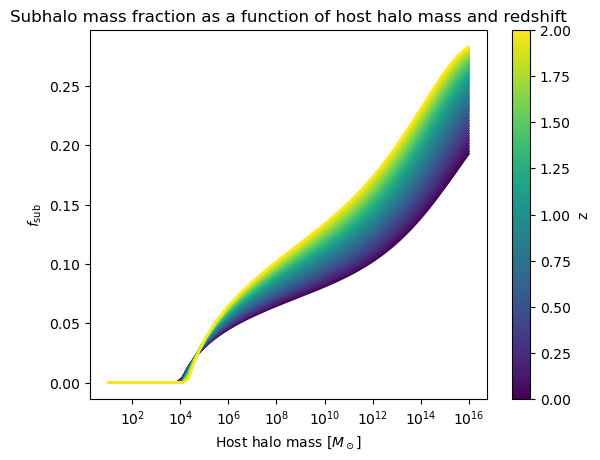

In [24]:
fig, ax = plt.subplots()

f_mz = aps_sub_t.fsh_list
cmap = plt.cm.viridis
norm = Normalize(vmin=np.min(aps_sub_t.z_ps), vmax=np.max(aps_sub_t.z_ps))

for i, z in enumerate(aps_sub_t.z_ps):
    ax.plot(aps_sub_t.M_grid, f_mz[:, i], color=cmap(norm(z)))

ax.set_xscale('log')
ax.set_xlabel(r'Host halo mass $[M_\odot]$')
ax.set_ylabel(r'$f_{\mathrm{sub}}$')

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('z')

plt.title('Subhalo mass fraction as a function of host halo mass and redshift')
plt.show()

3. Plots of the different matter power spectra for the minimum and maximum redshift values.

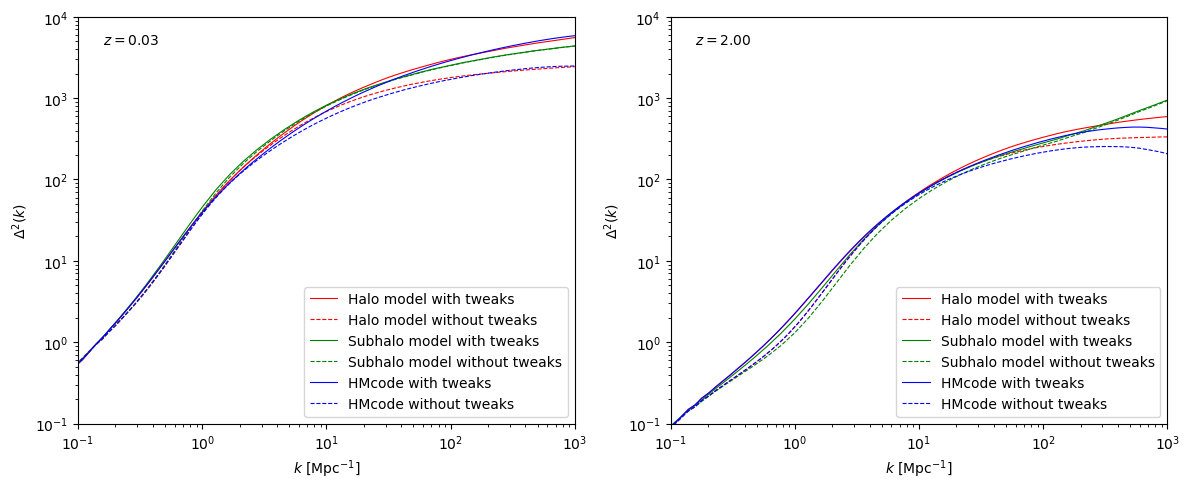

[plot_Pmm_comparison_1h] saved plots_Pmm_1h/Pmm_comparison_1h.png


In [6]:
plot_Pmm_comparison_1h(
    aps_halo_t,
    aps_halo_nt,
    aps_sub_t,
    aps_sub_nt,
    aps_hmcode_t,
    aps_hmcode_nt,
    save_dir='plots_Pmm_1h',
    show=True
)

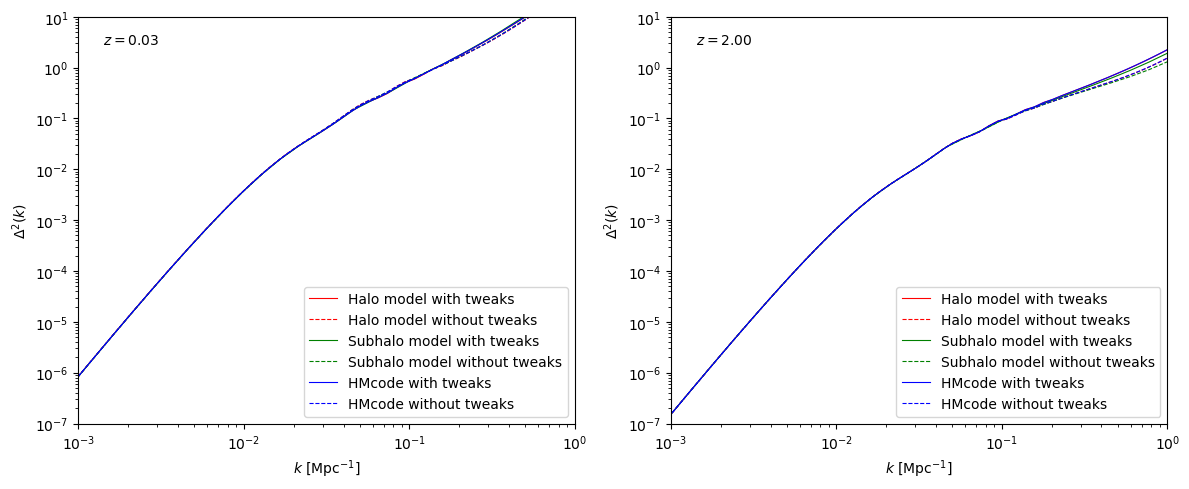

[plot_Pmm_comparison_2h] saved plots_Pmm_2h/Pmm_comparison_2h.png


In [7]:
plot_Pmm_comparison_2h(
    aps_halo_t,
    aps_halo_nt,
    aps_sub_t,
    aps_sub_nt,
    aps_hmcode_t,
    aps_hmcode_nt,
    save_dir='plots_Pmm_2h',
    show=True
)

4. Load DES datasets to perform the likelihood analysis.

In [8]:
NSIDE  = 1024
LMAX = 2048
VALID_PAIRS = [(i, j) for i in range(1, 6) for j in range(1, 5)]# if j > i]

ells = np.arange(LMAX+1)
ells_binned = np.loadtxt("ells_binned.csv", delimiter=",")

hdufid = fits.open('data/sim_3x2_fiducial_nla.fits')
cls_fid = hdufid['galaxy_shear_cl'].data

hdudes = fits.open('data/2pt_NG_final_2ptunblind_02_24_21_wnz_redmagic_covupdate.fits')

data_source = hdudes['nz_source'].data[:-1]
data_lens = hdudes['nz_lens'].data[:-1]

header_source = hdudes['nz_source'].header
header_lens = hdudes['nz_lens'].header

#redshift bins Redmagic
z_lims = np.array([0.15,0.35,0.5,0.65,0.8,0.9])

bin_number_source = 4
zs = np.array(data_source['Z_MID'])
zs_bins = []
zs_means = []
nz_source_dict = {}
ngal_source_dict = {}
sige_source_dict = {}
for i in range(bin_number_source):
    z = zs[(zs >= z_lims[i]) & (zs < z_lims[i+1])]
    zs_bins.append(np.array(z))
    zs_means.append(np.mean(z))
    nz_source_dict[i] = data_source['BIN' + str(i+1)]
    ngal_source_dict[i] = header_source['NGAL_' + str(i+1)] * (60 * 180 / np.pi)**2 # gal/arcmin^2  -> gal/str
    sige_source_dict[i] = header_source['SIG_E_' + str(i+1)]


bin_number_lens = 5
zl = np.array(data_lens['Z_MID'])
zl_bins = []
zl_means = []
nz_lens_dict = {}
ngal_lens_dict = {}
for i in range(bin_number_lens):
    z = zl[(zl >= z_lims[i]) & (zl < z_lims[i+1])]
    zl_bins.append(np.array(z))
    zl_means.append(np.mean(z))
    nz_lens_dict[i] = data_lens['BIN' + str(i+1)]
    ngal_lens_dict[i] = header_lens['NGAL_' + str(i+1)] * (60 * 180 / np.pi)**2 # gal/arcmin^2  -> gal/str

c = cosmology()
lmax_list_extended = np.zeros(5)
lmax_list_conservative = np.zeros(5)
R_min_extended = 6 #Mpc/h
R_min_conservative = 12 #Mpc/h
for i in range(5):
    nz_lens = nz_lens_dict[i]  
    z_mean = zl_means[i]
    chi_i = c.comoving_distance(z_mean)
    lmax_list_extended[i] = int(1/R_min_extended * chi_i)
    lmax_list_conservative[i] = int(1/R_min_conservative * chi_i)

#Biases REDMAGIC
galaxy_bias = np.array([1.7, 1.7, 1.7, 2.0, 2.0])  # lens galaxy bias for each lens bin
magnification_bias = np.array([1.3134, -0.5179, 0.3372, 2.2515, 1.9667])  # magnification bias for each lens bin
shear_calibration_bias = np.array([-0.0063,-0.0198,-0.0241,-0.0369])  # shear calibration bias for each source bin

#redshift shift for lens galaxies REDMAGIC
shift_params = np.array([0.006,0.001,0.004,-0.002,-0.007])
stretch_params = np.array([1,1,1,1,1.23])

#Intrinsic Alignment (IA)
IA_params = np.array([0.7,-1.36,-1.7,-2.5,1.0,0.62]) #a1,a2,alf1,alfa2,bTA,z0
C1_mean=5e-14 # h^2 Msun^-1 Mpc^3

cov  = np.load('cov_comb_full_nside1024.npy', allow_pickle=True).item()
#cov = np.load('cov_gaussian_full_nside1024_v3.npy', allow_pickle=True).item()
cov_dict = {eval(k): v for k, v in cov.items()}
cov      = block_diag(*[cov_dict[(i, j)] for (i, j) in VALID_PAIRS])
cov_inv  = np.linalg.inv(cov)
yerr     = np.sqrt(np.diag(cov))

N_ELL = len(ells_binned)
data_pcls = np.loadtxt(f'pcls_ge_full_nside{NSIDE}_old.csv', delimiter=',')

pcls_dict = {(i, j): np.zeros((2, N_ELL)) for (i, j) in VALID_PAIRS}
for row in data_pcls:
    i, j, s = int(row[0]), int(row[1]), int(row[2])
    if (i, j) in pcls_dict:
        pcls_dict[(i, j)][s, :] = row[3:]

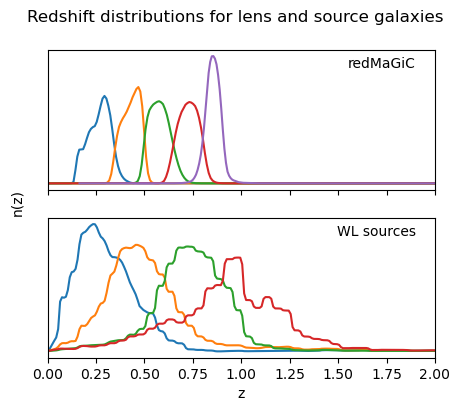

In [25]:
fig, ax = plt.subplots(2,1, figsize=(5, 4),sharex=True)
for i in range(5):
    z = (zl - zl_means[i]) / stretch_params[i] + zl_means[i] - shift_params[i]
    nz = nz_lens_dict[i] / stretch_params[i]
    norm = np.trapezoid(nz, z)
    nz = nz / norm
    ax[0].plot(z, nz, label=f'lens bin {i+1}')
    ax[0].set_xlim(0, 2)
    ax[0].set_yticks([])

for j in range(1, 5):
    nz = nz_source_dict[j-1]
    norm = np.trapezoid(nz, zs)
    nz = nz / norm
    ax[1].plot(zs, nz, label=f'source bin {j}')
    ax[1].set_xlabel('z')
    ax[1].set_xlim(0, 2)
    ax[1].set_yticks([])

ax[0].text(0.95, 0.95, 'redMaGiC', transform=ax[0].transAxes, ha='right', va='top')
ax[1].text(0.95, 0.95, 'WL sources', transform=ax[1].transAxes, ha='right', va='top')
fig.text(0.05, 0.5, 'n(z)', va='center', rotation='vertical')
fig.suptitle('Redshift distributions for lens and source galaxies')
plt.show()

5. Calculate the statistical results of the models using the functions in model_comparison.py.

In [10]:
result_hmcode, cls_hmcode,cls_gk_hmcode,cls_gI_hmcode,cls_muI_hmcode,cls_muk_hmcode, y_hmcode, m_hmcode = run_hmcode_stats(tweaks=True)
result_halo, cls_halo,cls_gk_halo,cls_gI_halo,cls_muI_halo,cls_muk_halo, y_halo, m_halo = run_halomodel_stats(tweaks=True,two_halo_term='halomodel')
result_subhalo, cls_subhalo, cls_gk_subhalo, cls_gI_subhalo, cls_muI_subhalo, cls_muk_subhalo, y_subhalo, m_subhalo = run_subhalo_stats(tweaks=True, fit=False,subhalo_pars_dir='pars_v6.npz',two_halo_term='halomodel')

halomodel_tweaks = [0.00152639, 1.3447891, 0.18992753, 0.51092, 0.79771424]
result_halo_fit, cls_halo_fit,cls_gk_halo_fit,cls_gI_halo_fit,cls_muI_halo_fit,cls_muk_halo_fit, y_halo_fit, m_halo_fit = run_halomodel_stats(tweaks=True,two_halo_term='halomodel',eta_amp=halomodel_tweaks[0], eta_exp=halomodel_tweaks[1], alpha_amp=halomodel_tweaks[2], alpha_exp=halomodel_tweaks[3], conc_boost=halomodel_tweaks[4])

subhalo_tweaks = [1.11924329, 1.20860481]#[2.17150518e+00, 1.63891522e+00]#[2.44722613e-03, 1.61238777e+00, 4.99081697e+00, 2.45381070e+00]
result_subhalo_fit, cls_subhalo_fit, cls_gk_subhalo_fit, cls_gI_subhalo_fit, cls_muI_subhalo_fit, cls_muk_subhalo_fit, y_subhalo_fit, m_subhalo_fit = run_subhalo_stats(tweaks=True, fit=True,subhalo_pars_dir='pars_v6.npz', alpha_amp = subhalo_tweaks[0],alpha_exp = subhalo_tweaks[1])

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using HMcode halo model with tweaks
[compute_cls] Cls calculated (binned)
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using standard halo model with tweaks
Computed Pmm using standard halo model without tweaks
[compute_cls] Cls calculated (binned)
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+16 Msun
min subhalo mass = 0.00e+00 Msun
max subhalo mass = 2.46e+15 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos and tweaks
[compute_cls] Cls calculated (binned)
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1

6. Plots of the angular GGL pwoer spectrum of the extended halo model.

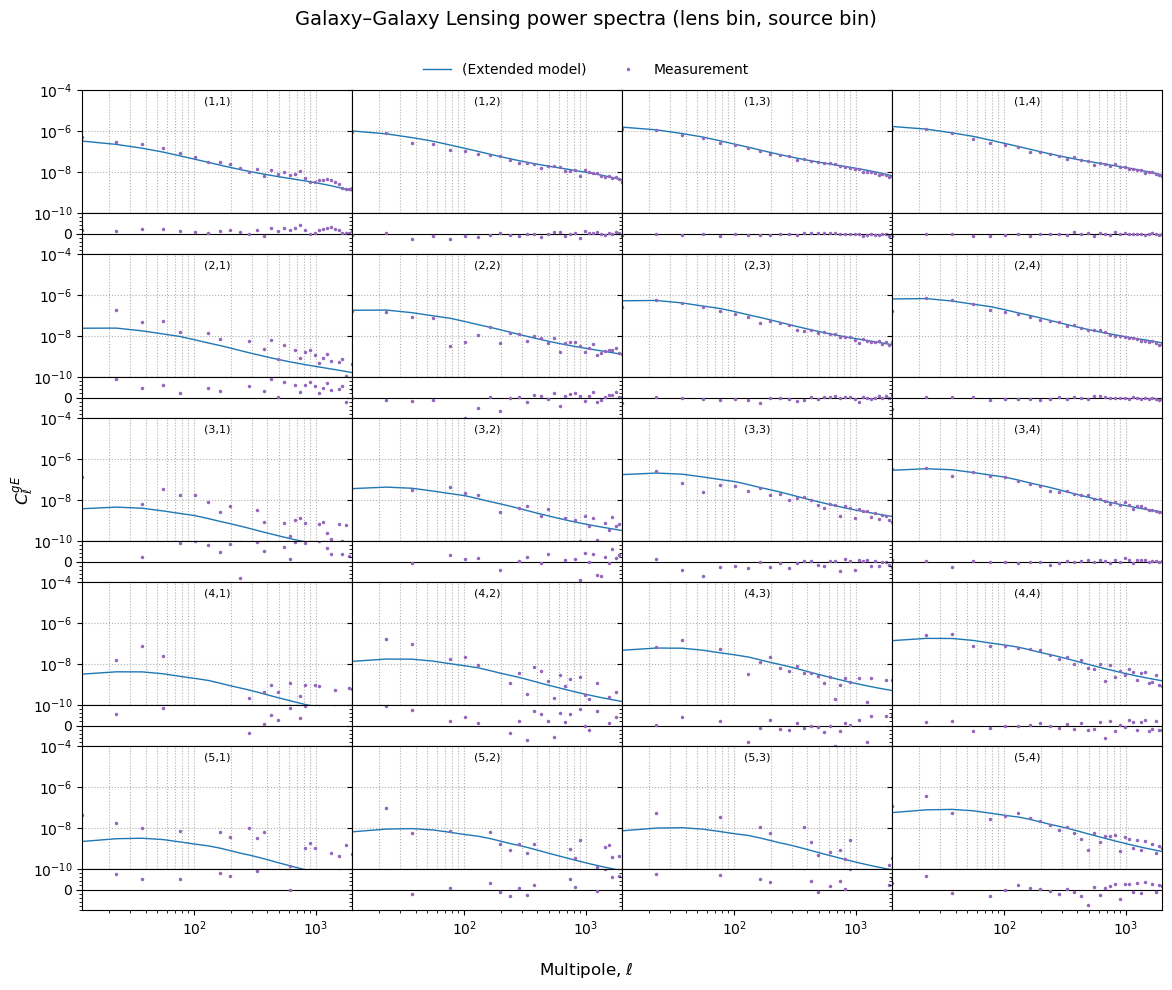

[plot_all_pairs_data_vs_model] saved plots_subhalo/all_pairs_Extended model.png


In [11]:
plot_all_pairs_data_vs_model(
    cls_subhalo,
    model_label='Extended model',
    save_dir='plots_subhalo',
    show='True'
)

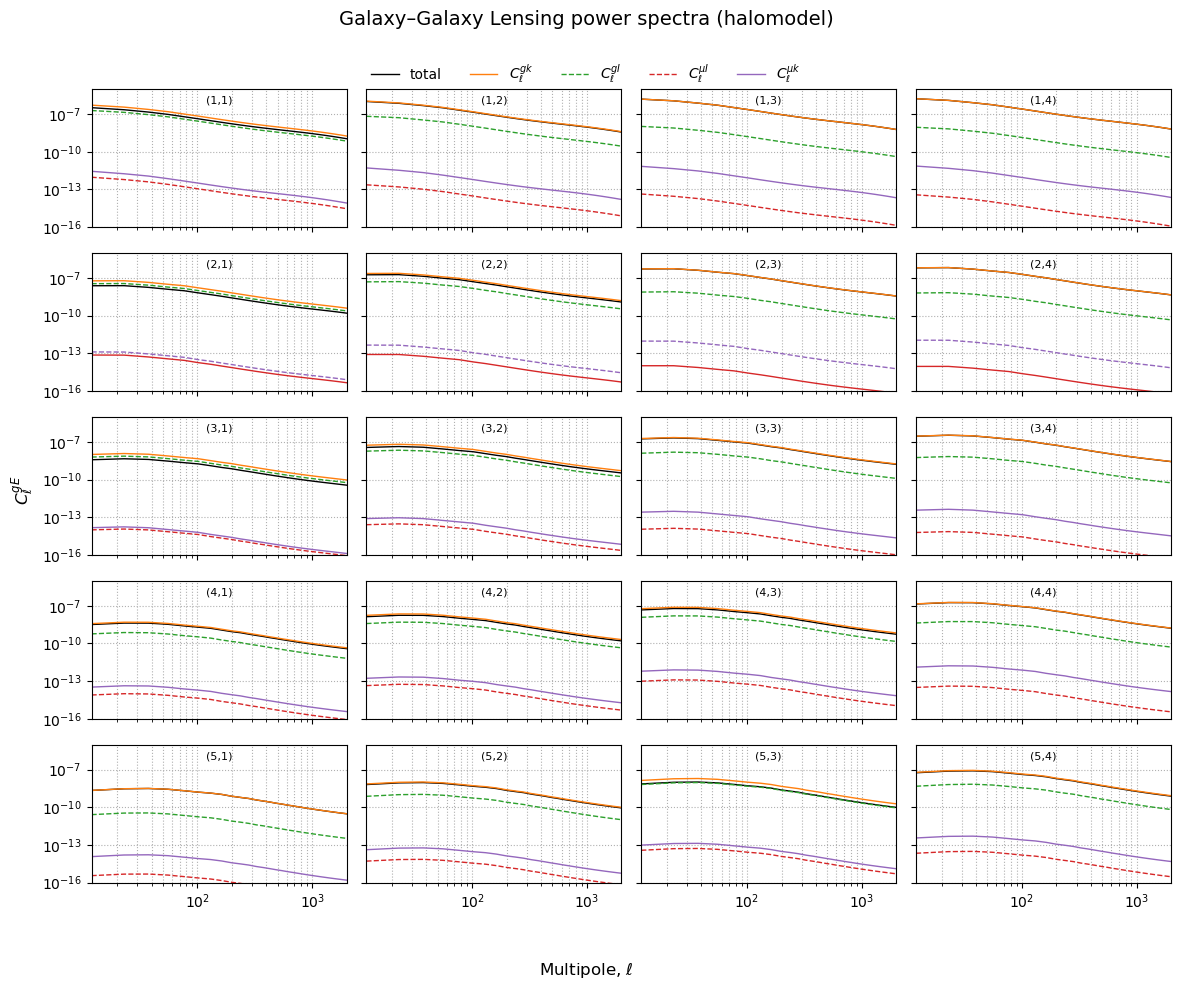

[plot_Cls] saved plots_halomodel/cls_all_pairs_halomodel.png


In [12]:
plot_Cls(
    cls_halo,
    cls_gk_halo,
    cls_gI_halo,
    cls_muI_halo,
    cls_muk_halo,
    model_label='halomodel',
    save_dir='plots_halomodel',
    show='True'
)

7. Display the results of the different models. 

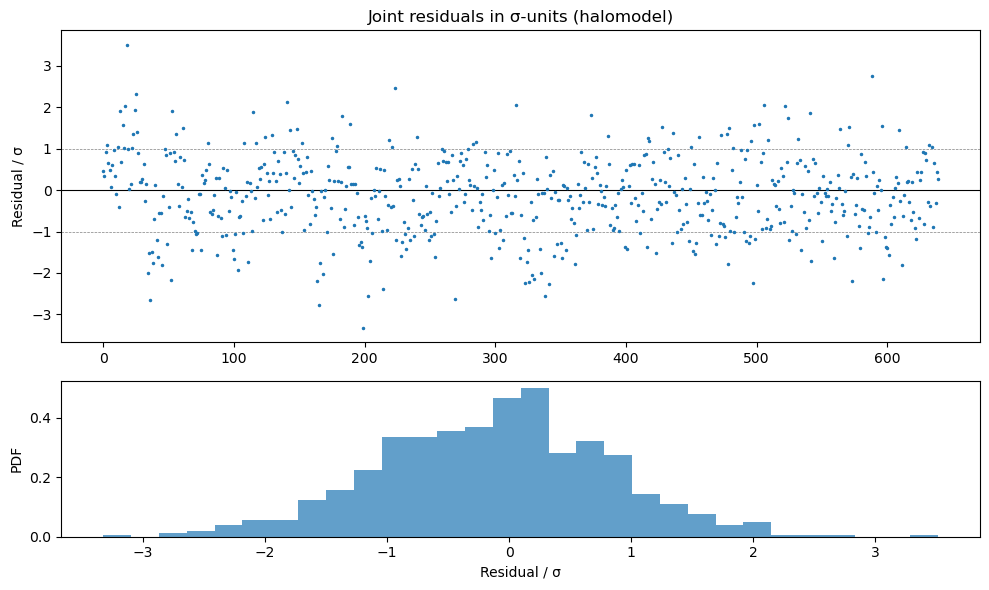

[plot_joint_residuals] saved plots_model/joint_residuals_halomodel.png


In [13]:
plot_joint_residuals(y_halo, m_halo, model_label='halomodel',
                         save_dir='plots_model', show=True)

In [14]:
display_results(result_halo, free_params=16)


  ───────────────────────────────────────────────────────────────────────────────────────────
  Model       Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ───────────────────────────────────────────────────────────────────────────────────────────
  halomodel   No cut                640-16        598.6        0.959     100.4         8947.2
              Extended              236-16        230.8        1.049      48.9         1551.8
              Conservative          156-16        139.0        0.993      34.0          735.4


In [15]:
display_results(result_halo_fit, free_params=16+5)


  ───────────────────────────────────────────────────────────────────────────────────────────
  Model       Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ───────────────────────────────────────────────────────────────────────────────────────────
  halomodel   No cut                640-21        571.9        0.924      94.8         8974.0
              Extended              236-21        200.0        0.930      46.7         1582.6
              Conservative          156-21        129.5        0.959      33.2          744.9


In [16]:
display_results(result_subhalo, free_params=16)


  ──────────────────────────────────────────────────────────────────────────────────────────────
  Model          Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ──────────────────────────────────────────────────────────────────────────────────────────────
  subhalomodel   No cut                640-16        592.0        0.949     101.2         8953.9
                 Extended              236-16        225.5        1.025      48.6         1557.1
                 Conservative          156-16        137.0        0.978      33.9          737.5


In [17]:
display_results(result_subhalo_fit, free_params=18)


  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Model                Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  subhalomodel (fit)   No cut                640-18        573.6        0.922      96.9         8972.2
                       Extended              236-18        204.5        0.938      47.1         1578.0
                       Conservative          156-18        130.4        0.945      33.3          744.0


In [18]:
display_results(result_hmcode, free_params=16)


  ─────────────────────────────────────────────────────────────────────────────────────────
  Model     Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ─────────────────────────────────────────────────────────────────────────────────────────
  HMcode    No cut                640-16        606.4        0.972     100.0         8939.4
            Extended              236-16        230.8        1.049      48.9         1551.8
            Conservative          156-16        138.5        0.989      34.0          736.0


In [19]:
result_hmcode_nt, _,_,_,_,_, _, _ = run_hmcode_stats(tweaks=False)
result_halo_nt, _,_,_,_,_, _, _ = run_halomodel_stats(tweaks=False)
result_subhalo_nt, _,_,_,_,_, _, _ = run_subhalo_stats(tweaks=False, fit=False,subhalo_pars_dir='pars.npz')

kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)


Note: redshifts have been re-sorted (earliest first)
Computed Pmm using HMcode halo model without tweaks
[compute_cls] Cls calculated (binned)
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.01, zmax = 2.00
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using standard halo model without tweaks
[compute_cls] Cls calculated (binned)
kmin = 1.00e-04 1/Mpc, kmax = 1.00e+03 1/Mpc
zmin = 0.00, zmax = 2.00
Mmin = 1.00e+01 Msun, Mmax = 1.00e+18 Msun
min subhalo mass = 6.97e-01 Msun
max subhalo mass = 5.43e+17 Msun
Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)
Computed Pmm using halo model with subhalos and without tweaks
[compute_cls] Cls calculated (binned)


In [20]:
display_results(result_hmcode_nt, free_params=16)


  ─────────────────────────────────────────────────────────────────────────────────────────
  Model     Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ─────────────────────────────────────────────────────────────────────────────────────────
  HMcode    No cut                640-16        686.1        1.099      91.2         8859.8
            Extended              236-16        232.5        1.057      48.8         1550.1
            Conservative          156-16        146.1        1.044      34.5          728.3


In [21]:
display_results(result_halo_nt, free_params=16)


  ───────────────────────────────────────────────────────────────────────────────────────────
  Model       Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ───────────────────────────────────────────────────────────────────────────────────────────
  halomodel   No cut                640-16        665.2        1.066      92.3         8880.6
              Extended              236-16        232.1        1.055      48.7         1550.5
              Conservative          156-16        146.0        1.043      34.5          728.4


In [22]:
display_results(result_subhalo_nt, free_params=16)


  ──────────────────────────────────────────────────────────────────────────────────────────────
  Model          Scale cut                dof           χ²       χ²/dof       SNR            Δχ²
  ──────────────────────────────────────────────────────────────────────────────────────────────
  subhalomodel   No cut                640-16        736.4        1.180      90.1         8809.4
                 Extended              236-16        231.9        1.054      48.7         1550.7
                 Conservative          156-16        146.3        1.045      34.5          728.2
